# EDA CLV

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../data/Online Retail.csv", encoding="ISO-8859-1") # encoding (usually UTF-8, ISO-8859-1(lalin1) for european special characters)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Numeric 3, Categorical 5

In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### negative values are present in the dataset. 

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### 2 Column contains null values.

In [8]:
df.duplicated().sum()

np.int64(5268)

### 5268 duplicate values are present

# Data Visualization

In [9]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [10]:
df["TotalPrice"].describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: TotalPrice, dtype: float64

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],dayfirst=True)

In [14]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
df["YearMonth"]

0         2010-12
1         2010-12
2         2010-12
3         2010-12
4         2010-12
           ...   
541904    2011-12
541905    2011-12
541906    2011-12
541907    2011-12
541908    2011-12
Name: YearMonth, Length: 541909, dtype: period[M]

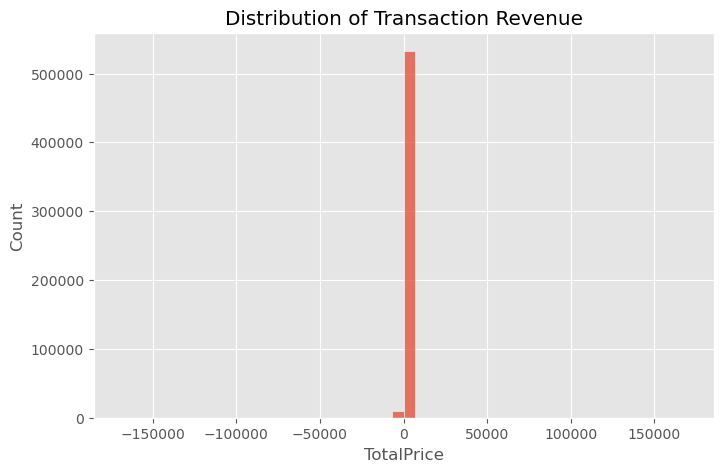

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalPrice"], bins=50)
plt.title("Distribution of Transaction Revenue")
plt.show()

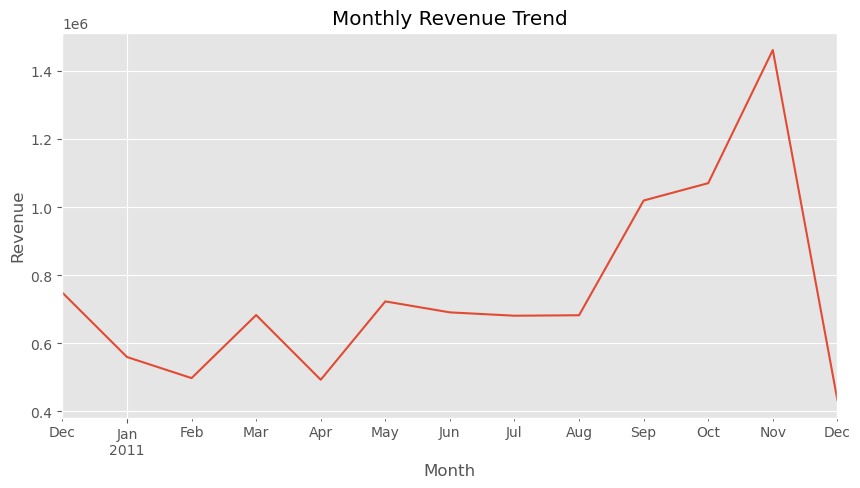

In [15]:
monthly_revenue = df.groupby("YearMonth")["TotalPrice"].sum()

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

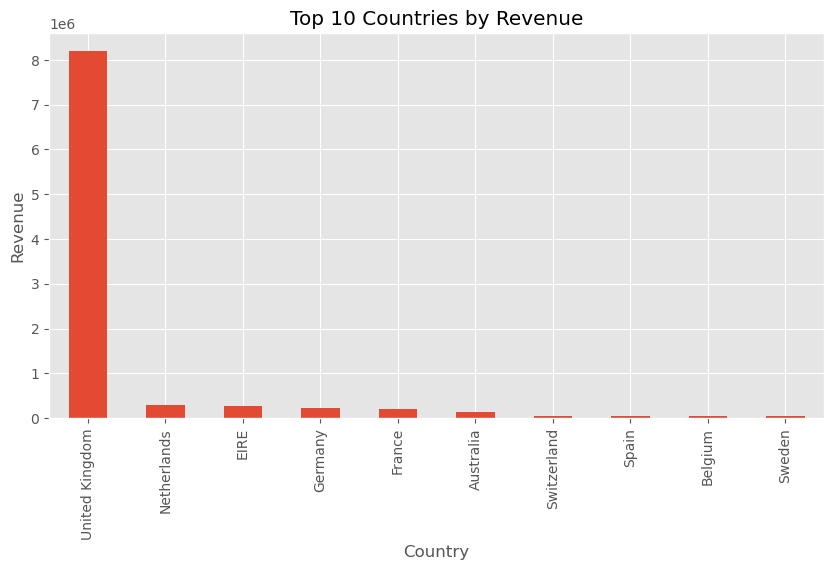

In [16]:
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()


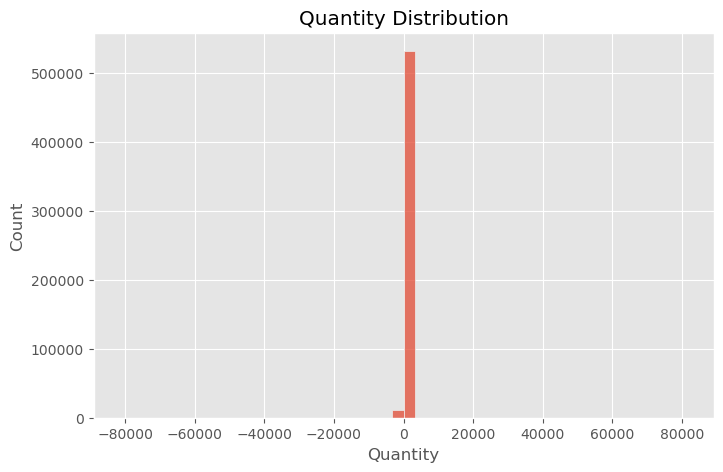

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"], bins=50)
plt.title("Quantity Distribution")
plt.show()


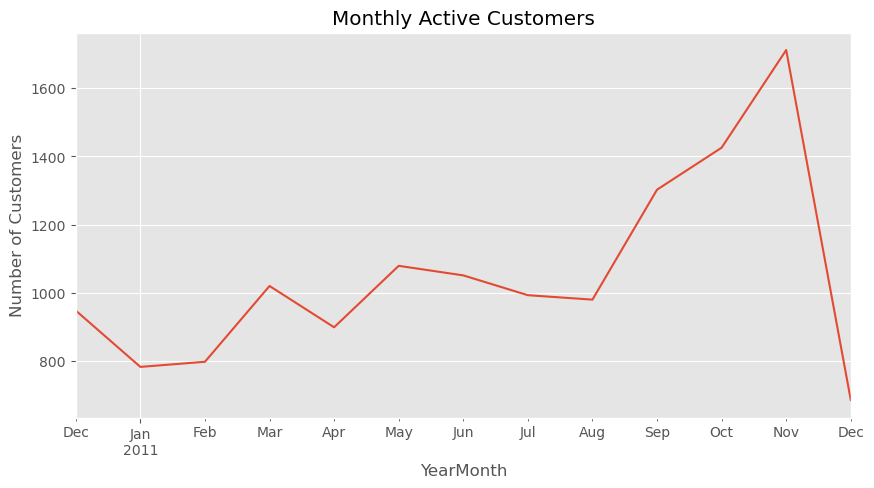

In [18]:
monthly_customers = df.groupby("YearMonth")["CustomerID"].nunique()

monthly_customers.plot(figsize=(10,5))
plt.title("Monthly Active Customers")
plt.ylabel("Number of Customers")
plt.show()


# END